In [1]:
# ==============================================================================
# ENVIRONMENT SETUP AND GITHUB AUTHENTICATION WITHOUT GOOGLE DRIVE
# Objective: Configure GitHub authentication and clone or update the repository
# directly inside the temporary Google Colab environment.
# ==============================================================================

# Import os for file-system operations and working-directory management.
import os

# Import userdata to retrieve the GitHub token from Colab Secrets.
from google.colab import userdata


# ------------------------------------------------------------------------------
# 1. PARAMETER CONFIGURATION
# ------------------------------------------------------------------------------

# Define the GitHub account and repository names.
GITHUB_USER = "pascual-francisco"
GITHUB_REPO = "INF-8239-Ciencia-de-Datos-II"

# Retrieve the GitHub personal access token from Colab Secrets.
GITHUB_TOKEN = userdata.get("TOKEN")

# Define the repository location directly inside the Colab environment.
REPO_DIR = f"/content/{GITHUB_REPO}"

# Define the author information used in Git commits.
GIT_AUTHOR_NAME = "Francisco Pascual"
GIT_AUTHOR_EMAIL = "pascual.francisco@gmail.com"


# ------------------------------------------------------------------------------
# 2. VERIFY THE GITHUB TOKEN
# ------------------------------------------------------------------------------

# Stop execution if the TOKEN secret is unavailable.
if not GITHUB_TOKEN:
    raise ValueError(
        "The GitHub token was not found. "
        "Add a Colab Secret named TOKEN before running this cell."
    )


# ------------------------------------------------------------------------------
# 3. GLOBAL GIT CONFIGURATION
# ------------------------------------------------------------------------------

# Configure the author name used in Git commits.
!git config --global user.name "{GIT_AUTHOR_NAME}"

# Configure the author email used in Git commits.
!git config --global user.email "{GIT_AUTHOR_EMAIL}"

# Configure main as the default branch name.
!git config --global init.defaultBranch main


# ------------------------------------------------------------------------------
# 4. DEFINE THE GITHUB REPOSITORY URL
# ------------------------------------------------------------------------------

# Define the authenticated URL used to clone or update the repository.
AUTH_URL = (
    f"https://{GITHUB_USER}:{GITHUB_TOKEN}"
    f"@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
)

# Define a clean URL that does not contain the GitHub token.
CLEAN_URL = (
    f"https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
)


# ------------------------------------------------------------------------------
# 5. CLONE OR UPDATE THE REPOSITORY
# ------------------------------------------------------------------------------

# Clone the repository when it is not available in the current Colab session.
if not os.path.exists(REPO_DIR):
    print(f"Cloning {GITHUB_REPO}...")

    # Clone the repository using the authenticated URL.
    !git clone "{AUTH_URL}" "{REPO_DIR}"

else:
    print("Repository already exists. Updating from the main branch...")

    # Navigate to the existing repository.
    %cd {REPO_DIR}

    # Retrieve and merge the latest changes using authenticated access.
    !git pull "{AUTH_URL}" main


# ------------------------------------------------------------------------------
# 6. REMOVE THE TOKEN FROM THE STORED REMOTE URL
# ------------------------------------------------------------------------------

# Navigate to the repository after cloning or updating it.
%cd {REPO_DIR}

# Store a clean GitHub URL as the permanent origin remote.
# This prevents the token from remaining visible in the Git configuration.
!git remote set-url origin "{CLEAN_URL}"


# ------------------------------------------------------------------------------
# 7. VERIFY THE ACTIVE ENVIRONMENT
# ------------------------------------------------------------------------------

# Display the active repository location.
print(f"\nEnvironment ready and located in:\n{os.getcwd()}")

# Display the configured Git remote without exposing the token.
print("\nConfigured Git remote:")
!git remote -v

# Display the current repository status.
print("\nCurrent Git status:")
!git status --short

Cloning INF-8239-Ciencia-de-Datos-II...
Cloning into '/content/INF-8239-Ciencia-de-Datos-II'...
remote: Enumerating objects: 818, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 818 (delta 139), reused 153 (delta 62), pack-reused 570 (from 1)
Receiving objects: 100% (818/818), 31.81 MiB | 11.77 MiB/s, done.
Resolving deltas: 100% (475/475), done.
/content/INF-8239-Ciencia-de-Datos-II

Environment ready and located in:
/content/INF-8239-Ciencia-de-Datos-II

Configured Git remote:
origin	https://github.com/pascual-francisco/INF-8239-Ciencia-de-Datos-II.git (fetch)
origin	https://github.com/pascual-francisco/INF-8239-Ciencia-de-Datos-II.git (push)

Current Git status:


# U02.DEMO01 — Sentiment Analysis

**Course:** INF-8239 Data Science II  
**Unit:** 02 — Natural Language Processing, Social Media, and Computer Vision  
**Instructor:** Edwin Ramón José Nolasco  
**Demonstration:** Sentiment Analysis  
**Dataset:** TweetEval  
**Environment:** Google Colab  

## Objective

Build a reproducible baseline for multiclass sentiment classification using the public TweetEval corpus. The model will classify tweets as negative, neutral, or positive using TF-IDF features and Logistic Regression.

## Workflow

1. Install and import the required libraries.
2. Load the TweetEval sentiment dataset.
3. Inspect the dataset structure and class distribution.
4. Build a leakage-free machine learning pipeline.
5. Train a Logistic Regression classifier.
6. Evaluate the model on validation and test data.
7. Analyze the confusion matrix and classification errors.
8. Run minimum reproducibility checks.

In [2]:
# ==============================================================================
# CELL 01 — IMPORT REQUIRED LIBRARIES
# Objective: Import the libraries required for data manipulation, visualization,
# dataset loading, text vectorization, model training, and model evaluation.
# ==============================================================================

# Import NumPy for numerical operations and validation checks.
import numpy as np

# Import pandas for tabular data manipulation and analysis.
import pandas as pd

# Import Matplotlib for creating and customizing visualizations.
import matplotlib.pyplot as plt

# Import Seaborn for creating statistical visualizations,
# including the confusion matrix heatmap.
import seaborn as sns

# Import the Hugging Face function used to load public datasets.
from datasets import load_dataset

# Import Pipeline to combine text vectorization and classification
# into a single reproducible machine learning workflow.
from sklearn.pipeline import Pipeline

# Import TF-IDF Vectorizer to transform raw text into numerical features.
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Logistic Regression as the multiclass sentiment classifier.
from sklearn.linear_model import LogisticRegression

# Import the metrics required to evaluate classification performance.
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Confirm that all required libraries were imported successfully.
print("All required libraries were imported successfully.")

All required libraries were imported successfully.


In [3]:
# ==============================================================================
# CELL 02 — IMPORT REQUIRED LIBRARIES
# Objective: Import the libraries required for dataset management, numerical
# operations, visualization, model construction, and performance evaluation.
# ==============================================================================

# Import NumPy for numerical operations and validation checks.
import numpy as np

# Import pandas for tabular data manipulation and exploratory analysis.
import pandas as pd

# Import Matplotlib and Seaborn for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Hugging Face function used to download public datasets.
from datasets import load_dataset

# Import Pipeline to combine text vectorization and classification
# into a single leakage-free workflow.
from sklearn.pipeline import Pipeline

# Import TF-IDF to transform raw text into numerical features.
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Logistic Regression as the multiclass sentiment classifier.
from sklearn.linear_model import LogisticRegression

# Import classification metrics for model evaluation.
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Libraries imported successfully.")


Libraries imported successfully.


In [4]:
# ==============================================================================
# CELL 02 — LOAD AND INSPECT THE TWEETEVAL SENTIMENT DATASET
# Objective: Load the TweetEval sentiment corpus, convert its official dataset
# splits into pandas DataFrames, and inspect the training class distribution.
# ==============================================================================

# Load the sentiment-analysis configuration of the public TweetEval dataset.
# The dataset includes predefined training, validation, and test splits.
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Define the human-readable class names according to their numerical encoding:
# 0 = negative, 1 = neutral, and 2 = positive.
labels = ["negative", "neutral", "positive"]

# Convert the official training split into a pandas DataFrame.
# This split will be used to fit the TF-IDF vectorizer and classifier.
train_df = dataset["train"].to_pandas()

# Convert the official validation split into a pandas DataFrame.
# This split will be used to evaluate model-development decisions.
valid_df = dataset["validation"].to_pandas()

# Convert the official test split into a pandas DataFrame.
# This split will be reserved for the final model evaluation.
test_df = dataset["test"].to_pandas()

# Display the dimensions of each dataset split.
# The output format is: (number of rows, number of columns).
print("Dataset dimensions:")
print(f"Training set:   {train_df.shape}")
print(f"Validation set: {valid_df.shape}")
print(f"Test set:       {test_df.shape}")

# Display the relative class distribution in the training set.
print("\nTraining class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

# Display the first five rows of the training DataFrame.
# This verifies the presence and content of the text and label columns.
print("\nFirst five training observations:")
display(train_df.head())

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset dimensions:
Training set:   (45615, 2)
Validation set: (2000, 2)
Test set:       (12284, 2)

Training class distribution:
label
0    0.155497
1    0.453206
2    0.391297
Name: proportion, dtype: float64

First five training observations:


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [5]:
# ==============================================================================
# CELL 03 — BUILD AND TRAIN THE SENTIMENT CLASSIFICATION PIPELINE
# Objective: Create a leakage-free pipeline that transforms tweets into TF-IDF
# features and trains a balanced Logistic Regression classifier.
# ==============================================================================

# Create a machine learning pipeline with two sequential steps:
# 1. Transform the raw tweets into numerical TF-IDF features.
# 2. Train a Logistic Regression classifier using those features.
model = Pipeline([

    # Define the text-vectorization step.
    ("tfidf", TfidfVectorizer(

        # Convert all text to lowercase to avoid treating words with different
        # capitalization as separate features.
        lowercase=True,

        # Extract both unigrams and bigrams:
        # (1, 1) represents individual words.
        # (2, 2) represents consecutive two-word combinations.
        ngram_range=(1, 2),

        # Ignore features that appear in fewer than three training documents.
        # This reduces noise caused by extremely rare terms.
        min_df=3,

        # Limit the vocabulary to a maximum of 25,000 features.
        # This controls memory usage and model complexity.
        max_features=25_000
    )),

    # Define the classification step.
    ("classifier", LogisticRegression(

        # Allow the optimization algorithm to perform up to 1,000 iterations
        # to find stable model coefficients.
        max_iter=1_000,

        # Automatically assign higher importance to underrepresented classes.
        # This helps reduce the effect of class imbalance.
        class_weight="balanced",

        # Set a fixed random seed to support reproducible results.
        random_state=42
    ))
])

# Train the complete pipeline using only the official training split.
# The pipeline first fits TF-IDF and then trains Logistic Regression
# using the numerical representation of the training tweets.
model.fit(train_df["text"], train_df["label"])

# Confirm that the training process finished successfully.
print("The sentiment classification pipeline was trained successfully.")

The sentiment classification pipeline was trained successfully.


F1 macro validación: 0.6409956505285027
              precision    recall  f1-score   support

    negative      0.556     0.676     0.610      3972
     neutral      0.654     0.536     0.589      5937
    positive      0.546     0.594     0.569      2375

    accuracy                          0.593     12284
   macro avg      0.585     0.602     0.589     12284
weighted avg      0.601     0.593     0.592     12284



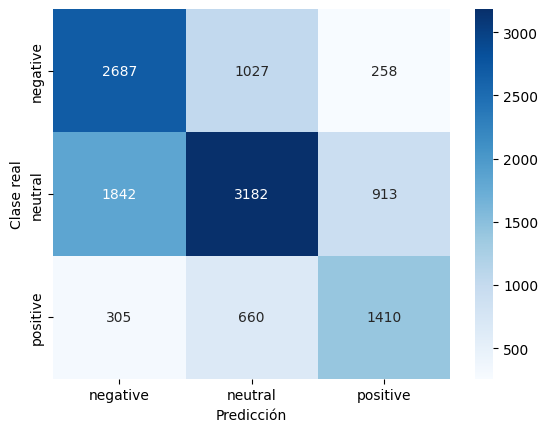

In [6]:
# ==============================================================================
# CELL 04 — EVALUATE THE MODEL ON VALIDATION AND TEST DATA
# Objective: Evaluate the trained sentiment classifier using macro F1,
# a classification report, and a confusion matrix.
# ==============================================================================

# Generate sentiment predictions for the validation dataset.
valid_pred = model.predict(valid_df["text"])

# Calculate and display the macro-averaged F1-score for validation.
# Macro F1 gives equal importance to each sentiment class.
print(
    "F1 macro validación:",
    f1_score(valid_df["label"], valid_pred, average="macro")
)

# Generate sentiment predictions for the test dataset.
test_pred = model.predict(test_df["text"])

# Display precision, recall, F1-score, and support for each sentiment class.
print(classification_report(
    test_df["label"],
    test_pred,
    target_names=labels,
    digits=3
))

# Calculate the confusion matrix by comparing actual and predicted labels.
cm = confusion_matrix(test_df["label"], test_pred)

# Display the confusion matrix as a heatmap.
# Rows represent actual classes and columns represent predicted classes.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

# Label the horizontal axis as the predicted sentiment class.
plt.xlabel("Predicción")

# Label the vertical axis as the actual sentiment class.
plt.ylabel("Clase real")

# Display the confusion matrix.
plt.show()

In [7]:
# ==============================================================================
# CELL 05 — EXAMINE CLASSIFICATION ERRORS
# Objective: Identify misclassified test examples and inspect a reproducible
# sample of their actual and predicted sentiment classes.
# ==============================================================================

# Create an independent copy of the test DataFrame.
errors = test_df.copy()

# Add the model predictions as a new column.
errors["prediction"] = test_pred

# Keep only the observations whose predicted label differs from the actual label.
errors = errors[errors["label"] != errors["prediction"]]

# Convert the actual numerical labels into human-readable sentiment names.
errors["real"] = errors["label"].map(dict(enumerate(labels)))

# Convert the predicted numerical labels into human-readable sentiment names.
errors["predicted"] = errors["prediction"].map(dict(enumerate(labels)))

# Display a reproducible random sample of 20 classification errors.
errors[["text", "real", "predicted"]].sample(20, random_state=42)

,text,real,predicted
9140,"With the most powerful binoculars, I cannot se...",neutral,positive
8021,@user The dividing lines that these new fascis...,negative,neutral
10816,@user #CapitalistArmy #MemeWars against libera...,negative,neutral
11987,How Medical Marijuana Could Combat the Opioid ...,neutral,negative
10374,2/2 #Yanukovich to #Ukraine ppl: @user give or...,neutral,negative
241,#Marijuana is medicine. 4 a very authoritative...,neutral,negative
3475,Vernon RCMP Cracking Down on Medical Marijuana...,neutral,negative
8541,Anyone else realised that getting a #Hatchimal...,neutral,negative
1217,Eat out and stay #Healthy. Yes. It is possible...,positive,neutral
4892,"Sodastream:.How to profit from Occupation, Opp...",neutral,negative


In [11]:
# ==============================================================================
# CELL 06 — RUN MINIMUM VALIDATION CHECKS
# Objective: Verify that predictions, labels, and pipeline components are
# consistent before interpreting the sentiment analysis results.
# ==============================================================================

# Verify that the model generated one prediction for every test observation.
assert len(test_pred) == len(test_df)

# Verify that all predicted labels belong to the expected classes:
# 0 = negative, 1 = neutral, 2 = positive.
assert set(np.unique(test_pred)).issubset({0, 1, 2})

# Verify that the TF-IDF transformation step exists in the pipeline.
assert "tfidf" in model.named_steps

# Verify that the classification step exists in the pipeline.
assert "classifier" in model.named_steps

# Display a confirmation message if all checks pass successfully.
print("Verificaciones superadas")

Verificaciones superadas


In [14]:
%%writefile /content/INF-8239-Ciencia-de-Datos-II/CHANGELOG.md
# Changelog

## [1.7.0] - 2026-10-07
### Added
- Completed LAB 01.
- Added TF-IDF pipelines using DummyClassifier, Complement Naive Bayes, and Logistic Regression.
- Added model metrics, confusion matrix, error analysis, and a reusable Joblib pipeline.
- Added automated model tests and an interactive Streamlit sentiment application.
- Added cloud-compatible dependencies through `requirements-cloud.txt`.

### Changed
- Updated project imports to use the existing `src` package.
- Updated Exercise 03 documentation to integrate LAB04 and LAB05.

### Validated
- Verified model prediction and pipeline persistence.
- Verified that the Streamlit application starts successfully in a clean environment.

All notable changes to this repository will be documented in this file.
## [1.6.0] - 2026-10-02

### Added
- Added the complete LAB04 workflow for selecting, downloading, reconstructing, auditing, and validating a public Spanish sentiment corpus.
- Added dataset candidate evaluation based on relevance, license, representativeness, quality, reproducibility, and risk.
- Added SHA-256 verification for the downloaded corpus.
- Added reconstruction of encoded reviews using the provided word dictionary and metadata.
- Added a processed three-class dataset containing positive, neutral, and negative sentiment labels.
- Added automated data-contract tests for required columns and non-empty text values.
- Added dataset documentation, audit results, and Colab portability configuration.
- Updated the repository-level `.gitignore` to exclude local `.env` files and raw and processed datasets from nested projects.

## [1.5.0] - 2026-09-24
### Added
- Created the folder structures for the NLP and Computer Vision projects.
- Created the folder structure for `Unit_02_Natural_Language_Processing/`:
- `app/`
- `data/raw/`
- `data/processed/`
- `docs/`
- `notebooks/`
- `reports/figures/`
- `scripts/`
- `src/`
- `tests/`

## [1.4.0] - 2026-09-24
### Added
- Added additional Green AI visualization outputs under `reports/figures/`.
- Added `model_comparison_f1.png` to compare F1 Macro performance across all evaluated models.
- Added `training_time_comparison.png` to compare median training times.
- Added `inference_time_comparison.png` to compare prediction latency across models.
- Added `model_size_comparison.png` to compare serialized model sizes.
- Added `green_ai_dashboard.png` consolidating F1, training time, inference time, and model size into a single report figure.
- Preserved existing required figures (`pareto.png` and `tsne_two_seeds.png`) and organized all report visualizations in `reports/figures/`.
- Added Green AI benchmarking workflow for U01.LAB03.
- Added six model configurations:
  - Logistic Regression
  - SVM (C=1)
  - SVM (C=10)
  - Random Forest (100 trees)
  - Random Forest (300 trees)
  - Histogram Gradient Boosting
- Added PCA dimensionality-reduction analysis.
- Added t-SNE visualizations using two different random seeds.
- Added Pareto frontier analysis for performance-cost trade-off evaluation.
- Added serialized model size and inference-time benchmarking.
- Added automated Pareto validation tests (`tests/test_green.py`).

### Generated
- Generated `reports/green_ai_results.csv`.
- Generated `reports/figures/pareto.png`.
- Generated `reports/figures/tsne_two_seeds.png`.
- Generated serialized model artifacts under `reports/models/`.

### Documentation
- Added Green AI interpretation and model-selection discussion.
- Added execution environment registration for reproducibility.

## [1.3.0] - 2026-09-22
- Added U01.LAB03 notebook

## [1.2.0] - 2026-09-22

### Added
- Completed the U01.LAB02 dataset audit and baseline modeling workflow.
- Defined the `Class` target and removed potential leakage variables.
- Added preprocessing for numerical and categorical features.
- Compared the `DummyClassifier` baseline against the RBF SVM.
- Added automated dataset-contract tests.
- Added dataset documentation, evaluation results, and conclusions.

### Results
- Dummy baseline F1-Macro: `0.3475`
- SVM F1-Macro: `0.6921`
- SVM accuracy: `0.6926`
- Positive-class recall: `0.6098`
- Dataset contract tests: `3 passed`

### Status
- U01.LAB02 guided workflow completed.
- The justified model adaptation and final Exercise 01 comparison remain pending.

## [1.1.0] - 2026-09-22

### Added
- Started U01.LAB02 public dataset search, selection, and audit workflow.
- Created the dataset profile and documented the analytical problem.
- Compared the Diabetic Retinopathy Debrecen and Dry Bean datasets.
- Applied the dataset acceptance criteria to both candidates.
- Documented dataset sources, targets, classes, dimensions, missing values, and potential leakage risks.
- Added reproducible access to the UCI Machine Learning Repository through the `ucimlrepo` API.
- Added the reusable `download_uci_dataset()` function in `data/data.py`.
- Downloaded and standardized the Diabetic Retinopathy Debrecen dataset as `data/raw/dataset.csv`.
- Added `ucimlrepo` to the project dependencies.

### Changed
- Extended the Exercise 01 notebook to preserve LAB01 as the baseline and begin the LAB02 workflow.
- Updated the data-access process to avoid dependence on personal Google Drive paths.

### Documentation
- Added `docs/dataset_profile.md`.
- Documented the preliminary dataset-selection rationale.
- Added an academic-use disclaimer and a preliminary target-leakage assessment.

### Status
- Reproducible dataset access completed.
- Dataset schema audit, target definition, preprocessing, baseline comparison, and automated tests remain in progress.

## [1.0.0] - 2026-09-21

### Added
- Completed U01.LAB01 guided SVM laboratory using the Breast Cancer dataset.
- Implemented a leakage-safe SVM pipeline with StandardScaler and SVC.
- Added a DummyClassifier baseline for model comparison.
- Performed hyperparameter optimization using GridSearchCV and StratifiedKFold.
- Evaluated model performance using F1-Macro, ROC-AUC, classification reports, and confusion matrices.
- Added reusable build_svm() model factory in src/inf8239_u01/models.py.
- Added unit tests for model validation and pipeline integrity in tests/test_models.py.
- Exported cross-validation results and trained model artifacts.

### Deliverables
- notebooks/01_svm_guiada.ipynb
- src/inf8239_u01/models.py
- tests/test_models.py
- reports/svm_cv_results.csv
- reports/svm_best.joblib

## [0.1.0] - 2026-09-18

### Added
- Established the Unit 01 project structure (LAB00-LAB03 and Exercise_01-Exercise_02).
- Configured baseline environment dependencies in requirements.txt.
- Added .gitignore rules for virtual environments, cache directories, build artifacts, and raw datasets.
- Implemented environment verification modules and corresponding unit tests.
- Created the notebook 00_verificacion.ipynb for environment and interpreter validation.
- Established repository structure for reports, figures, and evidence generation.

### Validated
- Verified automated test execution using pytest.
- Confirmed reproducibility through a local virtual environment setup.
- Validated repository synchronization with the remote GitHub repository.

Overwriting /content/INF-8239-Ciencia-de-Datos-II/CHANGELOG.md


In [ ]:
# ------------------------------------------------------------------------------
# Synchronize the U02.DEMO01 notebook with the repository
# ------------------------------------------------------------------------------

from google.colab import _message
from pathlib import Path
import json

# Destination path in the cloned repository
target = Path(
    "/content/INF-8239-Ciencia-de-Datos-II/"
    "Unit_02_Natural_Language_Processing/"
    "notebooks/"
    "U02.DEMO01.ipynb"
)

# Verify that the destination folder exists
if not target.parent.is_dir():
    raise FileNotFoundError(
        f"The destination folder does not exist: {target.parent}"
    )

# Retrieve the currently open Colab notebook
nb = _message.blocking_request("get_ipynb")

# Save the notebook in the repository
with target.open("w", encoding="utf-8") as file:
    json.dump(
        nb["ipynb"],
        file,
        ensure_ascii=False,
        indent=1
    )

print("Notebook saved successfully to:")
print(target)

In [10]:
# ==============================================================================
# AUTOMATIC COMMIT AND AUTHENTICATED PUSH
# Objective: Preserve empty directories, stage repository changes, create a
# commit when needed, push the current branch securely, and verify Git status.
# ==============================================================================

# Import os for environment and file-system operations.
import os

# Import stat to configure the temporary authentication script permissions.
import stat

# Import subprocess to execute Git commands and verify their results.
import subprocess

# Import Path for operating-system-independent path management.
from pathlib import Path

# Import userdata to retrieve the GitHub token from Colab Secrets.
from google.colab import userdata


# ------------------------------------------------------------------------------
# 1. DEFINE THE REPOSITORY CONFIGURATION
# ------------------------------------------------------------------------------

# Define the repository root directory.
REPO_PATH = Path(
    "/content/INF-8239-Ciencia-de-Datos-II"
)

# Define the Unit 02 directory.
UNIT_02_PATH = (
    REPO_PATH
    / "Unit_02_Natural_Language_Processing"
)

# Define the GitHub repository information.
GITHUB_USER = "pascual-francisco"
GITHUB_REPO = "INF-8239-Ciencia-de-Datos-II"

# Define the commit message.
COMMIT_MESSAGE = "chore: sync repository updates"

# Retrieve the GitHub token from Colab Secrets.
GITHUB_TOKEN = userdata.get("TOKEN")

# Define the clean GitHub remote URL.
CLEAN_REMOTE_URL = (
    f"https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
)


# ------------------------------------------------------------------------------
# 2. VALIDATE THE REPOSITORY AND TOKEN
# ------------------------------------------------------------------------------

# Confirm that the repository directory exists.
if not REPO_PATH.exists():
    raise FileNotFoundError(
        f"The repository was not found:\n{REPO_PATH}"
    )

# Confirm that the repository contains a .git directory.
if not (REPO_PATH / ".git").exists():
    raise FileNotFoundError(
        f"The directory is not a Git repository:\n{REPO_PATH}"
    )

# Confirm that the GitHub token is available.
if not GITHUB_TOKEN:
    raise ValueError(
        "The GitHub token was not found. "
        "Create a Colab Secret named TOKEN and enable notebook access."
    )


# ------------------------------------------------------------------------------
# 3. DEFINE A REUSABLE GIT COMMAND FUNCTION
# ------------------------------------------------------------------------------

def run_git(
    arguments: list[str],
    *,
    check: bool = True,
    capture_output: bool = False,
    environment: dict[str, str] | None = None
) -> subprocess.CompletedProcess:
    """
    Execute a Git command from the repository root.

    Parameters
    ----------
    arguments:
        Git arguments without the initial 'git'.
    check:
        Raise an error when the command returns a nonzero exit code.
    capture_output:
        Capture stdout and stderr instead of displaying them directly.
    environment:
        Optional environment variables used by the Git command.
    """

    return subprocess.run(
        ["git", *arguments],
        cwd=REPO_PATH,
        check=check,
        text=True,
        capture_output=capture_output,
        env=environment
    )


# ------------------------------------------------------------------------------
# 4. PREPARE EMPTY DIRECTORIES
# ------------------------------------------------------------------------------

print("=" * 70)
print("PREPARING EMPTY DIRECTORIES")
print("=" * 70)

if UNIT_02_PATH.exists():

    created_gitkeep_files = []

    # Walk through every directory inside Unit 02.
    for directory_path, directory_names, file_names in os.walk(
        UNIT_02_PATH
    ):
        # A directory is empty when it has no folders and no files.
        if not directory_names and not file_names:
            gitkeep_path = Path(directory_path) / ".gitkeep"
            gitkeep_path.touch()
            created_gitkeep_files.append(gitkeep_path)

    if created_gitkeep_files:
        print(
            f"Created {len(created_gitkeep_files)} "
            ".gitkeep file(s)."
        )
    else:
        print("No empty directories required a .gitkeep file.")

else:
    raise FileNotFoundError(
        f"The Unit 02 directory was not found:\n{UNIT_02_PATH}"
    )


# ------------------------------------------------------------------------------
# 5. DISPLAY THE CURRENT CHANGES
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("CHANGES DETECTED")
print("=" * 70)

# Display modified, deleted, renamed, and untracked files.
run_git([
    "status",
    "--short",
    "--untracked-files=all"
])


# ------------------------------------------------------------------------------
# 6. STAGE THE REPOSITORY CHANGES
# ------------------------------------------------------------------------------

# Stage all changes that are not excluded by .gitignore.
run_git([
    "add",
    "-A"
])

print("\n" + "=" * 70)
print("FILES STAGED FOR COMMIT")
print("=" * 70)

# Retrieve the exact list of staged changes.
staged_result = run_git(
    [
        "diff",
        "--cached",
        "--name-status"
    ],
    capture_output=True
)

staged_output = staged_result.stdout.strip()

# Display the staged changes.
if staged_output:
    print(staged_output)
else:
    print("No files are currently staged.")


# ------------------------------------------------------------------------------
# 7. CREATE A COMMIT ONLY WHEN CHANGES EXIST
# ------------------------------------------------------------------------------

if staged_output:
    print("\nCreating commit...")

    run_git([
        "commit",
        "-m",
        COMMIT_MESSAGE
    ])

    print(f"Commit created: {COMMIT_MESSAGE}")

else:
    print("\nNo new changes to commit.")


# ------------------------------------------------------------------------------
# 8. IDENTIFY THE CURRENT BRANCH
# ------------------------------------------------------------------------------

branch_result = run_git(
    [
        "branch",
        "--show-current"
    ],
    capture_output=True
)

current_branch = branch_result.stdout.strip()

if not current_branch:
    raise RuntimeError(
        "Git could not determine the current branch."
    )


# ------------------------------------------------------------------------------
# 9. CONFIGURE A CLEAN REMOTE URL
# ------------------------------------------------------------------------------

# Keep the permanent origin URL free from credentials.
run_git([
    "remote",
    "set-url",
    "origin",
    CLEAN_REMOTE_URL
])


# ------------------------------------------------------------------------------
# 10. CREATE TEMPORARY NON-INTERACTIVE AUTHENTICATION
# ------------------------------------------------------------------------------

# Define a temporary Git authentication helper.
askpass_path = Path("/tmp/github_colab_askpass.sh")

# Create a temporary script that responds to Git credential prompts.
askpass_content = """#!/bin/sh
case "$1" in
    *Username*) printf '%s\\n' "$GITHUB_USERNAME" ;;
    *Password*) printf '%s\\n' "$GITHUB_TOKEN" ;;
    *) printf '\\n' ;;
esac
"""

# Save the authentication helper.
askpass_path.write_text(
    askpass_content,
    encoding="utf-8"
)

# Allow only the current user to execute or modify the helper.
askpass_path.chmod(
    stat.S_IRUSR
    | stat.S_IWUSR
    | stat.S_IXUSR
)

# Create an environment for the authenticated Git push.
push_environment = os.environ.copy()

# Tell Git which temporary authentication helper to use.
push_environment["GIT_ASKPASS"] = str(askpass_path)

# Prevent Git from opening an interactive credential prompt.
push_environment["GIT_TERMINAL_PROMPT"] = "0"

# Supply the GitHub username only through the process environment.
push_environment["GITHUB_USERNAME"] = GITHUB_USER

# Supply the GitHub token only through the process environment.
push_environment["GITHUB_TOKEN"] = GITHUB_TOKEN


# ------------------------------------------------------------------------------
# 11. PUSH THE CURRENT BRANCH
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("PUSHING TO GITHUB")
print("=" * 70)
print(f"Current branch: {current_branch}")

try:
    # Push the current branch and establish its upstream relationship.
    run_git(
        [
            "push",
            "--set-upstream",
            "origin",
            current_branch
        ],
        environment=push_environment
    )

finally:
    # Delete the temporary authentication helper after the push attempt.
    if askpass_path.exists():
        askpass_path.unlink()


# ------------------------------------------------------------------------------
# 12. DISPLAY THE LATEST COMMITS
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("LATEST COMMITS")
print("=" * 70)

# Display the five most recent commits.
run_git([
    "log",
    "--oneline",
    "--decorate",
    "-5"
])


# ------------------------------------------------------------------------------
# 13. VERIFY THE FINAL SYNCHRONIZATION STATUS
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SYNCHRONIZATION STATUS")
print("=" * 70)

# Display the final branch and working-tree status.
run_git([
    "status",
    "--short",
    "--branch"
])

print("\nRepository synchronized successfully.")

PREPARING EMPTY DIRECTORIES
No empty directories required a .gitkeep file.

CHANGES DETECTED

FILES STAGED FOR COMMIT
A	Unit_02_Natural_Language_Processing/notebooks/U02.DEMO01.ipynb

Creating commit...
Commit created: chore: sync repository updates

PUSHING TO GITHUB
Current branch: main

LATEST COMMITS

FINAL SYNCHRONIZATION STATUS

Repository synchronized successfully.
